# Symmetry-Based Magnon Band Analysis Demo

This notebook presents a complete workflow for symmetry-based analysis of magnetic materials and magnon band structures. All results and figures are included for demonstration, so the notebook can be fully understood without running the code, although it is fully executable in a Julia environment with the required packages.

The demo illustrates the following key steps:
- Symmetry-constrained magnon band calculations
- Symmetry group identification of magnetic systems
- Symmetry-based band degeneracy analysis at selected k-points

## Inputs and Workflow

Main input files:
- `POSCAR_JULIA`: crystal structure.
- `INFO_JULIA`: magnetic configuration for the Julia symmetry-analysis pipeline.
- `INFO_FORT`: magnetic interaction and solver input for the Fortran magnon solver.

Generated during the workflow:
- `neighbor_info.txt`: symmetry-constrained neighbor information generated automatically by the Julia preprocessing step.
- `output.txt`: runtime output from the magnon solver.
- `dispersion.txt`: computed magnon-band data.
- `symmetries.txt`: symmetry operations identified for the system.


Typical workflow in this notebook:
1. Initialize the Julia-based symmetry-analysis environment and the magnon-solver interface (Fortran backend).
2. Compute magnon bands:
   - Generate symmetry-aware neighbor information
   - Run the magnon solver
   - Plot the magnon dispersion
3. Perform symmetry analysis:
   - Extract symmetries
   - Decompose bands into irreducible representations

## Environment Setup

The following cell loads the Julia-based symmetry-analysis tools and the
magnon-solver interface used throughout this notebook.

In [1]:
include("../symmetry-analyzer/material-analyzer/initialization.jl")
init()

Initializing symmetry-analyzer and magnon-solver (~10 seconds)...
Done.


## Example 1: Cu3TeO6

### 1. Magnon band calculation
We first use Cu3TeO6 as a demonstration case. The workflow below generates
symmetry-constrained neighbor information, runs the magnon solver, and plots
the resulting magnon dispersion along a high-symmetry path.

generate neighbor information to 8th order(symmetry: on)...
done
bulk computing...
 0.50000 -0.50000  0.50000
 0.25000  0.25000  0.25000
 0.50000 -0.50000  0.50000
finished


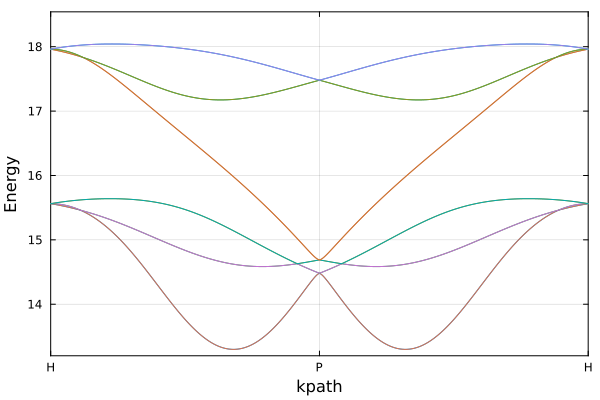

In [20]:
CuTeO_dir = "./Cu3TeO6/primitive-cell"

# 🔹 Step 1: Generate symmetry-aware neighbor information
generate_neighobor_info(CuTeO_dir)

# 🔹 Step 2: Compute magnon spectrum
run_magnon_solver(CuTeO_dir)

# 🔹 Step 3: Plot magnon dispersion
plot_magnon_dispersion(CuTeO_dir;klabel=["H","P","H"])

**Interpretation of above magnon band**

From the plotted magnon spectrum, the system contains a total of twelve magnon bands. Although only six branches are visually resolved in the plot, each branch is in fact doubly degenerate.

At generic k-points, the bands are twofold degenerate. At high-symmetry points, the degeneracies are further enhanced:
- `H`: 6-fold degeneracy
- `P`: 4-fold degeneracy
- `Generic k`: 2-fold degeneracy

Note: The features observed here are consistent with experimental and theoretical results reported in [Weiliang Yao et al., Nat Phys 14, 1011–1015 (2018)](https://www.nature.com/articles/s41567-018-0213-x).

### 2. Symmetry analysis

The next step is to show that these degeneracy features are not only visible in the magnon dispersion, but can also be understood directly from symmetry. This is achieved by analyzing the symmetry operations of the system and performing irreducible-representation decomposition using the code.

In [3]:
# 🔹 Step 1: Get all symmetry operations
cell = read_structure(CuTeO_dir)
get_symmetries(cell, CuTeO_dir);

Getting symmetries...
Done. Symmetries saved.


In [11]:
# 🔹 Step 2: Perform irreducible-representation decomposition at H point = [0.5, -0.5, 0.5]
H = [
     0.0 0.0 0.0  0.5
     0.0 0.0 0.0 -0.5
     0.0 0.0 0.0  0.5
]
get_irrep_decomposition_at_k(cell, CuTeO_dir; k=H)

Constructing co-irrepresentation...
Constructing representation in magnon basis...
Getting irrep decomposition...
Done.
Irrep decomposition at 
irrep1  dim=2   0
irrep2  dim=4   0
irrep3  dim=6   2


**Interpretation at H point**

The result shows that at the `H` point there are three types of irreducible representations, but only irrep3 (dimension = 6) appears in the decomposition with multiplicity 2. This means that the magnon states at `H` point are organized into two copies of a 6-dimensional irreducible representation. Since the dimension of an irreducible representation directly corresponds to the degeneracy of the energy levels, a 6-dimensional irrep leads to a 6-fold degeneracy, and two copies correspond to two independent sets of such degenerate bands. Therefore, the magnon spectrum at the H point consists of two 6-fold degeneracy, which matches exactly with the degeneracy observed in the magnon dispersion plot.

In [12]:
# 🔹 Step 3: Perform irreducible-representation decomposition at P point = [0.25, 0.25, 0.25]
P = [
     0.0 0.0 0.0  0.25
     0.0 0.0 0.0  0.25
     0.0 0.0 0.0  0.25
]
get_irrep_decomposition_at_k(cell, CuTeO_dir; k=P)

Constructing co-irrepresentation...
Constructing representation in magnon basis...
Getting irrep decomposition...
Done.
Irrep decomposition at 
irrep1  dim=4   1
irrep2  dim=4   1
irrep3  dim=4   1


**Interpretation at P point**

At the `P` point, the decomposition shows three types of irreducible representations, each with dimension 4 and multiplicity 1. This means that the magnon states at this k-point are organized into three different 4-dimensional irreducible representations. Since the dimension of an irreducible representation determines the degeneracy of the energy levels, each 4-dimensional irrep corresponds to a 4-fold degeneracy. Therefore, the magnon spectrum at the P point exhibits 4-fold-degenerate bands, which is consistent with the degeneracy observed in the magnon dispersion.

In [13]:
# 🔹 Step 4: Perform irreducible-representation decomposition at arbitrary point [kx,ky,kz]
k = [
     1.0 0.0 0.0  0.0
     0.0 1.0 0.0  0.0
     0.0 0.0 1.0  0.0
]
get_irrep_decomposition_at_k(cell, CuTeO_dir; k=k)

Constructing co-irrepresentation...
Constructing representation in magnon basis...
Getting irrep decomposition...
Done.
Irrep decomposition at 
irrep1  dim=2   6


**Interpretation at generic k point**

Similar to the previous analysis, this result shows that the magnon states decompose into six copies of a 2-dimensional irreducible representation. This implies that the bands are always 2-fold degenerate at generic k-points. This is consistent with the doubly degenerate bands observed throughout the Brillouin zone in the magnon dispersion.


### 3. Summary
From the symmetry analysis, we find that:
- At the `H` point, the bands are 6-fold degenerate
- At the `P` point, the bands are 4-fold degenerate
- At `generic k` points, the bands are 2-fold degenerate

These results are fully consistent with the magnon dispersion and confirm that the full degeneracy structure of the magnon bands is completely determined by symmetry. This demonstrates a clear agreement between symmetry analysis and numerical results.

## Example 2: RuO2 (brief demonstration)

We apply the same symmetry-analysis pipeline to RuO2 to demonstrate its generality.

**Key observations along high-symmetry lines**
- Two of the high-symmetry lines (`X-S` and `X-Γ`) exhibit 2-fold degeneracy.
- This feature is confirmed directly from the irreducible-representation decomposition along the line.**

This demonstrates that the workflow can capture symmetry-protected degeneracies along lines, and correctly identifies regions without degeneracy, highlighting the method's general applicability.

Note: The features observed here are consistent with theoretical results reported in [Libor Šmejkal
 et al., Phys. Rev. Lett. 131, 256703 (2023)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.131.256703).

### 1. Magnon band calculation


generate neighbor information to 7th order(symmetry: on)...
done
bulk computing...
 0.50000 -0.50000  0.00000
 0.00000  0.00000  0.00000
 0.50000  0.50000  0.00000
 0.00000  0.50000  0.00000
 0.00000  0.00000  0.00000
finished


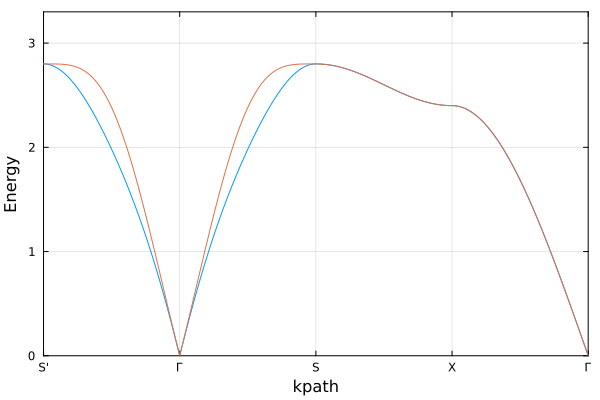

In [16]:
RuO2_dir = "./RuO2"

# 🔹 Step 1: Generate symmetry-aware neighbor information
generate_neighobor_info(RuO2_dir)

# 🔹 Step 2: Compute magnon spectrum
run_magnon_solver(RuO2_dir)

# 🔹 Step 3: Plot magnon dispersion
plot_magnon_dispersion(RuO2_dir;klabel=["S'","Γ","S","X","Γ"])
#

### 2. Symmetry analysis

In [17]:
# 🔹 Step 1: Get all symmetry operations
cell = read_structure(RuO2_dir)
get_symmetries(cell, RuO2_dir);

Getting symmetries...
Done. Symmetries saved.


In [18]:
# 🔹 Step 2: Perform irreducible-representation decomposition along X-S (0.5, ky, 0)
k = [
     0.0 0.0 0.0  0.5
     0.0 1.0 0.0  0.0
     0.0 0.0 0.0  0.0
]
get_irrep_decomposition_at_k(cell, RuO2_dir; k=k)

Constructing co-irrepresentation...
Constructing representation in magnon basis...
Getting irrep decomposition...
Done.
Irrep decomposition at 
irrep1  dim=2   1
irrep2  dim=2   0


In [19]:
# 🔹 Step 3: Perform irreducible-representation decomposition along Γ-X (kx, 0, 0)
k = [
     1.0 0.0 0.0  0.0
     0.0 0.0 0.0  0.0
     0.0 0.0 0.0  0.0
]
get_irrep_decomposition_at_k(cell, RuO2_dir; k=k)

Constructing co-irrepresentation...
Constructing representation in magnon basis...
Getting irrep decomposition...
Done.
Irrep decomposition at 
irrep1  dim=2   1
irrep2  dim=2   0


## Overall Summary of two examples

- **Cu3TeO6:** H point 6-fold, P point 4-fold, generic k 2-fold degeneracy  
- **RuO2:** along X-S and X-Γ lines 2-fold degeneracy, other high-symmetry lines single bands  

These results confirm that the degeneracy structure of magnon bands is fully determined by symmetry and correctly captured by the workflow across different magnetic systems.